cnn pentru 0-9 labels de digits in gray

In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) 
])


train_dataset = datasets.MNIST(root='../data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='../data', train=False, download=True, transform=transform)


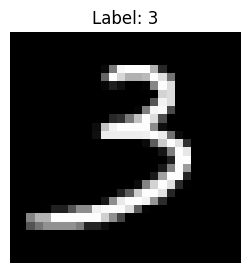

In [7]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size = 64, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

import matplotlib.pyplot as plt

dataiter = iter(train_loader)
images, labels = next(dataiter)


img = images[0]
label = labels[0].item()

plt.figure(figsize=(3, 3))
plt.imshow(img.squeeze(), cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off") 
plt.show()


In [8]:
import torch.nn.functional as F

class MnistCNN(nn.Module):
    def __init__(self):
        super(MnistCNN, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.hidden_layer = nn.Linear(1600, 128)
        self.output_layer = nn.Linear(128, 10)

    def forward(self, logits):
        logits = self.pool(F.relu(self.conv1(logits)))

        logits = self.pool(F.relu(self.conv2(logits)))

        logits = logits.view(-1, 1600)
        logits = F.relu(self.hidden_layer(logits))
        logits = self.output_layer(logits)
        return logits

device = torch.device("cpu")
model = MnistCNN().to(device)
print("merge")

merge


In [9]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 5

for epoch in range(epochs):
    running_loss = 0.0
     
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()
        if i % 100 == 99:    
            print(f'[Epoch {epoch + 1}, Batch {i + 1}] loss: {running_loss / 100:.3f}')
            running_loss = 0.0
            
print("finished training")


[Epoch 1, Batch 100] loss: 0.659
[Epoch 1, Batch 200] loss: 0.181
[Epoch 1, Batch 300] loss: 0.125
[Epoch 1, Batch 400] loss: 0.106
[Epoch 1, Batch 500] loss: 0.094
[Epoch 1, Batch 600] loss: 0.074
[Epoch 1, Batch 700] loss: 0.070
[Epoch 1, Batch 800] loss: 0.071
[Epoch 1, Batch 900] loss: 0.059
[Epoch 2, Batch 100] loss: 0.043
[Epoch 2, Batch 200] loss: 0.051
[Epoch 2, Batch 300] loss: 0.056
[Epoch 2, Batch 400] loss: 0.045
[Epoch 2, Batch 500] loss: 0.048
[Epoch 2, Batch 600] loss: 0.041
[Epoch 2, Batch 700] loss: 0.044
[Epoch 2, Batch 800] loss: 0.043
[Epoch 2, Batch 900] loss: 0.039
[Epoch 3, Batch 100] loss: 0.031
[Epoch 3, Batch 200] loss: 0.032
[Epoch 3, Batch 300] loss: 0.031
[Epoch 3, Batch 400] loss: 0.027
[Epoch 3, Batch 500] loss: 0.034
[Epoch 3, Batch 600] loss: 0.033
[Epoch 3, Batch 700] loss: 0.032
[Epoch 3, Batch 800] loss: 0.035
[Epoch 3, Batch 900] loss: 0.034
[Epoch 4, Batch 100] loss: 0.023
[Epoch 4, Batch 200] loss: 0.025
[Epoch 4, Batch 300] loss: 0.021
[Epoch 4, 

In [10]:
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10,000 test images: {100 * correct / total:.2f}%')

Accuracy of the network on the 10,000 test images: 98.99%
